# 03 — Parameter exploration: how the physics knobs shape the spectrum

This notebook sweeps the main physical parameters of an L-edge multiplet
calculation and plots how each one reshapes the spectrum. All sweeps run
through the fast `getXAS()` bootstrap path, so each frame takes
milliseconds.

**Sweeps in this notebook**
1. **d-electron count** — the full Ti⁴⁺ (d⁰) → Ni²⁺ (d⁸) series.
2. **Crystal field 10Dq** — edit the `.ban` recipe on the fly and
   re-diagonalize with `assemble_and_diagonalize()`.
3. **Charge-transfer Δ** — same mechanism on a different parameter.
4. **Temperature** — Boltzmann population of the ground manifold
   (requires `max_gs > 1`).
5. **Broadening widths** — the `(beam_fwhm, gamma1, gamma2)` trio.

The 10Dq and Δ sweeps rewrite the `.ban` file in a tempdir and re-run
the assembler. For the broadening and temperature sweeps the Hamiltonian
is unchanged; only the spectrum layer recomputes.

In [1]:
# Make the notebook runnable from anywhere: chdir to the repo root so
# that relative paths like 'tests/reference_data/...' resolve correctly
# whether you launched jupyter from the repo root or from notebooks/.
import os
from pathlib import Path
_here = Path.cwd()
for _anc in [_here, *_here.parents]:
    if (_anc / "multitorch").is_dir() and (_anc / "tests" / "reference_data").is_dir():
        os.chdir(_anc)
        break
print("working dir:", Path.cwd())

working dir: /Users/afollmer/Follmer_UCD/Follmer_Lab/Code/multiplets/multitorch


## Sweep 1 — d-electron count (Ti⁴⁺ through Ni²⁺)

The `tests/reference_data/` directory carries eight pre-computed ttmult
runs covering the full 3d L-edge series. The spectra shift up in
absolute energy across the series and the multiplet structure changes
dramatically with d-count.

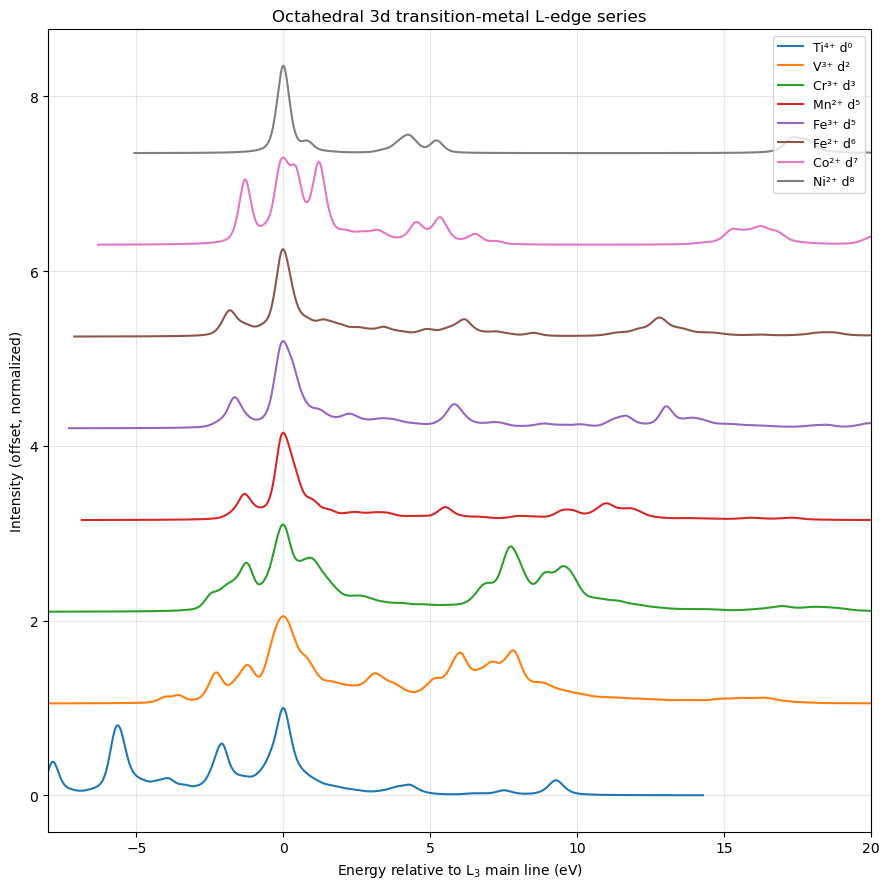

In [2]:
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np
from multitorch.api.plot import getXAS

REFROOT = Path("tests/reference_data")

# (case_id, human label) ordered by d-electron count
CASES = [
    ("ti4_d0_oh",  "Ti⁴⁺ d⁰"),
    ("v3_d2_oh",   "V³⁺ d²"),
    ("cr3_d3_oh",  "Cr³⁺ d³"),
    ("mn2_d5_oh",  "Mn²⁺ d⁵"),
    ("fe3_d5_oh",  "Fe³⁺ d⁵"),
    ("fe2_d6_oh",  "Fe²⁺ d⁶"),
    ("co2_d7_oh",  "Co²⁺ d⁷"),
    ("ni2_d8_oh",  "Ni²⁺ d⁸"),
]

fig, ax = plt.subplots(figsize=(9, 9))
for i, (case, label) in enumerate(CASES):
    x, y = getXAS(str(REFROOT / case / f"{case}.ban_out"),
                  T=80.0, beam_fwhm=0.3, gamma1=0.3, gamma2=0.5)
    y_norm = y / y.max()
    ax.plot(x.numpy() - float(x[y.argmax()]),  # zero at main peak
            y_norm.numpy() + i * 1.05, lw=1.5, label=label)

ax.set_xlabel("Energy relative to L$_3$ main line (eV)")
ax.set_ylabel("Intensity (offset, normalized)")
ax.set_title("Octahedral 3d transition-metal L-edge series")
ax.set_xlim(-8, 20)
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Helper — sweep a `.ban` parameter and return broadened spectra

For physical-parameter sweeps (10Dq, CT energy) we need to re-run the
Hamiltonian assembler with a modified `.ban` file. Rather than edit the
library, we do the simplest thing: read the original `.ban` as text,
swap one value, write to a tempdir, and re-run `getXAS()` via a
lightweight wrapper that plumbs the re-assembled result through the
standard `sticks → broaden` path.

In [3]:
import tempfile, re, shutil, os
from multitorch.hamiltonian.assemble import assemble_and_diagonalize
from multitorch.spectrum.sticks import get_sticks
from multitorch.spectrum.broaden import pseudo_voigt

# Tiny adapter: BanResult (from assemble_and_diagonalize) has .triads[].T,
# but get_sticks expects a BanOutput with .triad_list[].M. We wrap one in
# the other just for the duration of this call.
class _BanOutputAdapter:
    def __init__(self, ban_result):
        class _T:
            def __init__(self, tr):
                self.gs_sym = tr.gs_sym
                self.act_sym = tr.act_sym
                self.fs_sym = tr.fs_sym
                self.Eg = tr.Eg
                self.Ef = tr.Ef
                self.M = tr.T
        self.triad_list = [_T(tr) for tr in ban_result.triads]


def spectrum_from_modified_ban(fixture_dir: Path, ban_text: str, *,
                               T=80.0, beam_fwhm=0.2, gamma1=0.2, gamma2=0.4,
                               nbins=2000):
    """Write ban_text to a tempdir, rerun assemble_and_diagonalize, broaden."""
    case = fixture_dir.name
    with tempfile.TemporaryDirectory() as td:
        td = Path(td)
        # Copy the RME files unchanged
        for ext in ("rme_rcg", "rme_rac"):
            shutil.copy(fixture_dir / f"{case}.{ext}", td / f"{case}.{ext}")
        # Write the modified .ban
        (td / f"{case}.ban").write_text(ban_text)
        # Assemble + diagonalize
        result = assemble_and_diagonalize(
            str(td / f"{case}.rme_rcg"),
            str(td / f"{case}.rme_rac"),
            str(td / f"{case}.ban"),
        )
    # Broaden
    ban = _BanOutputAdapter(result)
    E_sticks, M_sticks, _ = get_sticks(ban, T=T, max_gs=1)
    if E_sticks.numel() == 0:
        raise ValueError("no sticks produced — parameter change may be pathological")
    x = torch.linspace(float(E_sticks.min()) - 5.0,
                       float(E_sticks.max()) + 5.0,
                       nbins, dtype=torch.float64)
    med = 0.5 * (float(E_sticks.min()) + float(E_sticks.max()))
    y = pseudo_voigt(
        x, E_sticks, M_sticks,
        fwhm_g=beam_fwhm, fwhm_l=gamma1, fwhm_l2=gamma2,
        med_energy=med, mode="legacy",
    )
    return x, y


# Sanity check: unmodified .ban should reproduce the stock getXAS within
# float64 noise on the parts of the grid they both cover.
fixture = REFROOT / "ni2_d8_oh"
original_ban_text = (fixture / "ni2_d8_oh.ban").read_text()
x0, y0 = spectrum_from_modified_ban(fixture, original_ban_text)
print(f"unmodified sweep reproduces a spectrum with {y0.shape[0]} bins, "
      f"ymax = {float(y0.max()):.4f}")

unmodified sweep reproduces a spectrum with 2000 bins, ymax = 1.1843


## Sweep 2 — Crystal field 10Dq

In the `.ban` recipe the crystal-field strength appears in the `XHAM`
line as the second value (for octahedral symmetry: `XHAM 2 1.0 <tendq>`).
We sweep it from 0.8 eV (weak field, deeper multiplet structure) to
1.6 eV (strong field, more singlet character).

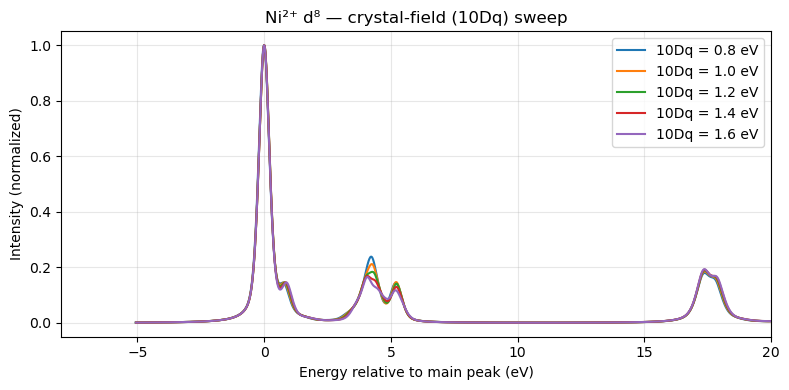

In [4]:
def replace_xham_tendq(ban_text: str, new_tendq: float) -> str:
    # XHAM line looks like ' XHAM 2 1.0 1.200   ' for Oh (2 operators: H, 10Dq).
    # Substitute the second numerical value.
    def sub(m):
        return f"{m.group(1)}{new_tendq:.4f}"
    return re.sub(r"(\bXHAM\s+\d+\s+[\d.]+\s+)([-\d.]+)", sub, ban_text, count=1)


fixture = REFROOT / "ni2_d8_oh"
base_ban = (fixture / "ni2_d8_oh.ban").read_text()

fig, ax = plt.subplots(figsize=(8, 4))
for tendq in [0.8, 1.0, 1.2, 1.4, 1.6]:
    modified = replace_xham_tendq(base_ban, tendq)
    x, y = spectrum_from_modified_ban(fixture, modified,
                                      beam_fwhm=0.3, gamma1=0.3, gamma2=0.5)
    y_norm = y / y.max()
    ax.plot(x.numpy() - float(x[y.argmax()]), y_norm.numpy(),
            label=f"10Dq = {tendq:.1f} eV", lw=1.5)

ax.set_xlabel("Energy relative to main peak (eV)")
ax.set_ylabel("Intensity (normalized)")
ax.set_title("Ni²⁺ d⁸ — crystal-field (10Dq) sweep")
ax.set_xlim(-8, 20)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sweep 3 — Charge-transfer energy Δ

The charge-transfer energy Δ = E(d⁸L) − E(d⁹L̲) is controlled by the
`EG2` line in the `.ban` DEF block. Lower Δ mixes ligand-hole character
into the ground state and redistributes spectral weight into the
charge-transfer satellite.

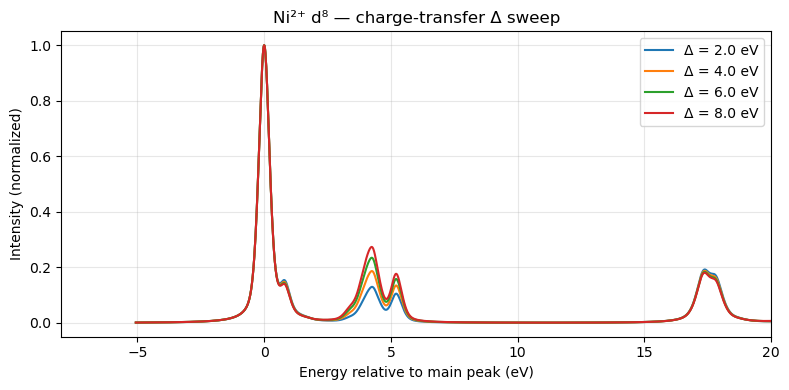

In [5]:
def replace_eg2(ban_text: str, new_eg2: float) -> str:
    def sub(m):
        return f"{m.group(1)}{new_eg2:.4f}"
    return re.sub(r"(\bDEF\s+EG2\s*=\s*)([-\d.]+)", sub, ban_text, count=1)


fig, ax = plt.subplots(figsize=(8, 4))
for dE in [2.0, 4.0, 6.0, 8.0]:
    modified = replace_eg2(base_ban, dE)
    x, y = spectrum_from_modified_ban(fixture, modified,
                                      beam_fwhm=0.3, gamma1=0.3, gamma2=0.5)
    ax.plot(x.numpy() - float(x[y.argmax()]),
            y.numpy() / float(y.max()),
            label=f"Δ = {dE:.1f} eV", lw=1.5)

ax.set_xlabel("Energy relative to main peak (eV)")
ax.set_ylabel("Intensity (normalized)")
ax.set_title("Ni²⁺ d⁸ — charge-transfer Δ sweep")
ax.set_xlim(-8, 20)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sweep 4 — Temperature (Boltzmann population)

At low temperature only the lowest ground state contributes; at higher
temperature, thermally populated excited states of the ground manifold
add their own spectra. `getXAS()` exposes `max_gs` to control how many
ground states to retain.

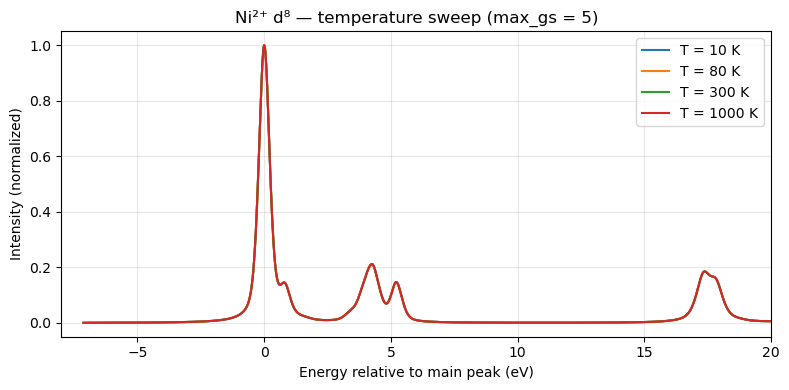

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
for T in [10.0, 80.0, 300.0, 1000.0]:
    x, y = getXAS(str(fixture / "ni2_d8_oh.ban_out"),
                  T=T, max_gs=5,
                  beam_fwhm=0.3, gamma1=0.3, gamma2=0.5)
    ax.plot(x.numpy() - float(x[y.argmax()]),
            y.numpy() / float(y.max()),
            label=f"T = {T:g} K", lw=1.5)
ax.set_xlabel("Energy relative to main peak (eV)")
ax.set_ylabel("Intensity (normalized)")
ax.set_title("Ni²⁺ d⁸ — temperature sweep (max_gs = 5)")
ax.set_xlim(-8, 20)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sweep 5 — Broadening (resolution trade-off)

The broadening sweep in `01_quickstart.ipynb` varied one width at a
time. Here we show the full (narrow, medium, wide) envelope to highlight
how the multiplet fine structure resolves under better resolution.

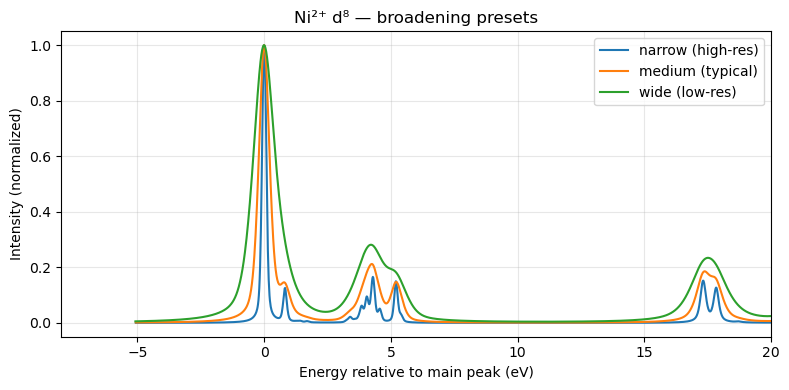

In [8]:
presets = [
    ("narrow (high-res)",    dict(beam_fwhm=0.10, gamma1=0.10, gamma2=0.20)),
    ("medium (typical)",     dict(beam_fwhm=0.30, gamma1=0.30, gamma2=0.50)),
    ("wide (low-res)",       dict(beam_fwhm=0.60, gamma1=0.60, gamma2=1.00)),
]

fig, ax = plt.subplots(figsize=(8, 4))
for label, params in presets:
    x, y = getXAS(str(fixture / "ni2_d8_oh.ban_out"), T=80.0, **params)
    ax.plot(x.numpy() - float(x[y.argmax()]), y.numpy() / float(y.max()),
            label=label, lw=1.5)
ax.set_xlabel("Energy relative to main peak (eV)")
ax.set_ylabel("Intensity (normalized)")
ax.set_title("Ni²⁺ d⁸ — broadening presets")
ax.set_xlim(-8, 20)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## What you can do from here

- **Fit experimental data.** All tensors are `float64` and
  `requires_grad`-compatible, so you can drop `getXAS()` inside a
  PyTorch optimization loop and fit 10Dq, Δ, slater, soc to a measured
  spectrum.
- **New ions.** Copy any `tests/reference_data/<case>/` directory,
  regenerate the `.rme_rcg` / `.rme_rac` / `.ban_out` with the Fortran
  toolchain (see `pyttmult/`), and the bootstrap pipeline will pick it
  up without any further work.
- **Pure-PyTorch pipeline.** The full `calcXAS(element=..., valence=..., ...)`
  form that skips the Fortran step is a Phase 5 goal and currently
  raises `NotImplementedError`. Follow `TASK-017` onwards in
  `.claude/orchestration/INDEX.md`.